# TimeSformer MAE Training

Train TimeSformer encoder with VideoMAE (masked autoencoding) pretraining.

**Section 3.3**: Learning Threshold Representations
- 7-frame depth panorama sequences
- 90% masking ratio
- Divided space-time attention
- Self-supervised reconstruction

## Setup

In [1]:
import os
import sys
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
from tqdm.notebook import tqdm
import time
from datetime import datetime

# Adjust path if running from model folder
if os.path.basename(os.getcwd()) == 'model':
    os.chdir('..')

from config import get_mae_config, get_small_config
from timesformer_mae import TimeSformerMAE
from dataset import create_dataloaders

print("✓ Imports successful")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

✓ Imports successful
PyTorch version: 2.10.0.dev20251029+cu128
CUDA available: True
GPU: NVIDIA GeForce RTX 5060 Laptop GPU


## Configuration

In [2]:
# =============================================================================
# TRAINING CONFIGURATION - ADJUST THESE!
# =============================================================================

# Data paths (YOUR LOCAL PATHS)
DATA_ROOT = r"C:\\Users\\shrua\\OneDrive\\Desktop\\threshold project\\threshold\\data"

# Model size: 'small' for testing, 'default' for full training
MODEL_SIZE = 'small'  # Change to 'default' for full training

# Training hyperparameters
NUM_EPOCHS = 5  # Start with 5 for testing, use 100+ for full training
BATCH_SIZE = 4  # Reduce if OOM (out of memory)
LEARNING_RATE = 1e-4
WEIGHT_DECAY = 0.05
TRAIN_SPLIT = 0.85

# Hardware
NUM_WORKERS = 0  # Keep 0 for Windows
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

# Output
OUTPUT_DIR = r"C:\\Users\\shrua\\OneDrive\\Desktop\\threshold project\\threshold\\models\\output"
SAVE_FREQ = 5  # Save checkpoint every N epochs

print("Configuration:")
print(f"  Model size: {MODEL_SIZE}")
print(f"  Epochs: {NUM_EPOCHS}")
print(f"  Batch size: {BATCH_SIZE}")
print(f"  Device: {DEVICE}")
print(f"  Output: {OUTPUT_DIR}")

Configuration:
  Model size: small
  Epochs: 5
  Batch size: 4
  Device: cuda
  Output: C:\\Users\\shrua\\OneDrive\\Desktop\\threshold project\\threshold\\models\\output


In [3]:
# Create output directories
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(os.path.join(OUTPUT_DIR, 'checkpoints'), exist_ok=True)
print(f"✓ Output directories created")

✓ Output directories created


## Load Data

In [4]:
print("Loading dataset...")

train_loader, val_loader = create_dataloaders(
    data_root=DATA_ROOT,
    batch_size=BATCH_SIZE,
    train_split=TRAIN_SPLIT,
    num_workers=NUM_WORKERS,
)

print(f"✓ Data loaded")
print(f"  Train batches: {len(train_loader)}")
print(f"  Val batches: {len(val_loader)}")
print(f"  Train samples: {len(train_loader.dataset)}")
print(f"  Val samples: {len(val_loader.dataset)}")

Loading dataset...
Found 40 threshold CSV files
Loaded 10474 threshold sequences from 40 files
Train size: 8902, Val size: 1572
✓ Data loaded
  Train batches: 2226
  Val batches: 393
  Train samples: 8902
  Val samples: 1572


## Create Model

In [5]:
# Get config
if MODEL_SIZE == 'small':
    config = get_small_config()
    print("Using SMALL model (for testing)")
else:
    config = get_mae_config()
    print("Using DEFAULT model (for training)")

# Create model
model = TimeSformerMAE(config)
model = model.to(DEVICE)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"\n✓ Model created")
print(f"  Total parameters: {total_params:,}")
print(f"  Trainable parameters: {trainable_params:,}")
print(f"  Encoder parameters: {sum(p.numel() for p in model.encoder.parameters()):,}")
print(f"  Decoder parameters: {sum(p.numel() for p in model.decoder.parameters()):,}")

Configuration:
  Image size: 32x64
  Patch size: 4x4
  Patches per frame: 128 (8x16)
  Total frames: 7
  Total patches: 896
  Visible patches (~10%): ~89
  Masked patches (~90%): ~806
Using SMALL model (for testing)

✓ Model created
  Total parameters: 5,531,824
  Trainable parameters: 5,531,824
  Encoder parameters: 4,980,992
  Decoder parameters: 550,576


## Setup Training

In [6]:
# Optimizer
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
    betas=(0.9, 0.95),
)

# Learning rate scheduler
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=NUM_EPOCHS,
    eta_min=LEARNING_RATE * 0.01,
)

print("✓ Optimizer and scheduler created")

✓ Optimizer and scheduler created


In [7]:
# Training history
history = {
    'train_loss': [],
    'val_loss': [],
    'learning_rate': [],
    'epoch_time': [],
}

best_val_loss = float('inf')

## Training Functions

In [8]:
def train_one_epoch(model, dataloader, optimizer, device, epoch):
    """
    Train for one epoch.
    """
    model.train()
    total_loss = 0
    
    pbar = tqdm(dataloader, desc=f"Epoch {epoch} [Train]")
    
    for batch in pbar:
        pixel_values = batch['pixel_values'].to(device)
        
        # Forward pass
        loss, pred, mask = model(pixel_values)
        
        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        # Accumulate loss
        total_loss += loss.item()
        
        # Update progress bar
        pbar.set_postfix({'loss': f'{loss.item():.4f}'})
    
    avg_loss = total_loss / len(dataloader)
    return avg_loss


def validate(model, dataloader, device, epoch):
    """
    Validate the model.
    """
    model.eval()
    total_loss = 0
    
    with torch.no_grad():
        pbar = tqdm(dataloader, desc=f"Epoch {epoch} [Val]")
        
        for batch in pbar:
            pixel_values = batch['pixel_values'].to(device)
            
            loss, pred, mask = model(pixel_values)
            
            total_loss += loss.item()
            pbar.set_postfix({'loss': f'{loss.item():.4f}'})
    
    avg_loss = total_loss / len(dataloader)
    return avg_loss


def save_checkpoint(model, optimizer, epoch, loss, filename):
    """
    Save model checkpoint.
    """
    checkpoint = {
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'loss': loss,
    }
    torch.save(checkpoint, filename)
    print(f"  💾 Saved: {os.path.basename(filename)}")


print("✓ Training functions defined")

✓ Training functions defined


## 🚀 START TRAINING

Run the cell below to start training!

In [9]:
print("="*80)
print(f"STARTING TRAINING: {NUM_EPOCHS} epochs")
print("="*80)
print(f"Start time: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print()

for epoch in range(NUM_EPOCHS):
    epoch_start = time.time()
    
    # Train
    train_loss = train_one_epoch(model, train_loader, optimizer, DEVICE, epoch)
    
    # Validate
    val_loss = validate(model, val_loader, DEVICE, epoch)
    
    # Update scheduler
    scheduler.step()
    
    # Record history
    epoch_time = time.time() - epoch_start
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['learning_rate'].append(optimizer.param_groups[0]['lr'])
    history['epoch_time'].append(epoch_time)
    
    # Print epoch summary
    print(f"\nEpoch {epoch}/{NUM_EPOCHS-1}")
    print(f"  Train Loss: {train_loss:.4f}")
    print(f"  Val Loss:   {val_loss:.4f}")
    print(f"  LR:         {optimizer.param_groups[0]['lr']:.6f}")
    print(f"  Time:       {epoch_time:.1f}s")
    
    # Save checkpoint
    if (epoch + 1) % SAVE_FREQ == 0:
        checkpoint_path = os.path.join(
            OUTPUT_DIR, 'checkpoints', f'checkpoint_epoch_{epoch:04d}.pt'
        )
        save_checkpoint(model, optimizer, epoch, val_loss, checkpoint_path)
    
    # Save best model
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_path = os.path.join(OUTPUT_DIR, 'checkpoints', 'best_model.pt')
        save_checkpoint(model, optimizer, epoch, val_loss, best_path)
        print(f"  ⭐ New best model! (val_loss: {val_loss:.4f})")
    
    print("-" * 80)

print("\n" + "="*80)
print("TRAINING COMPLETE!")
print("="*80)
print(f"End time: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print(f"Best validation loss: {best_val_loss:.4f}")
print(f"Total time: {sum(history['epoch_time'])/60:.1f} minutes")

STARTING TRAINING: 5 epochs
Start time: 2025-11-08 23:02:47



Epoch 0 [Train]:   0%|          | 0/2226 [00:00<?, ?it/s]

Epoch 0 [Val]:   0%|          | 0/393 [00:00<?, ?it/s]


Epoch 0/4
  Train Loss: 0.4564
  Val Loss:   0.2895
  LR:         0.000091
  Time:       131.0s
  💾 Saved: best_model.pt
  ⭐ New best model! (val_loss: 0.2895)
--------------------------------------------------------------------------------


Epoch 1 [Train]:   0%|          | 0/2226 [00:00<?, ?it/s]

...

Epoch 3 [Val]:   0%|          | 0/393 [00:00<?, ?it/s]


Epoch 3/4
  Train Loss: 0.1574
  Val Loss:   0.1334
  LR:         0.000010
  Time:       130.4s
  💾 Saved: best_model.pt
  ⭐ New best model! (val_loss: 0.1334)
--------------------------------------------------------------------------------


Epoch 4 [Train]:   0%|          | 0/2226 [00:00<?, ?it/s]

Epoch 4 [Val]:   0%|          | 0/393 [00:00<?, ?it/s]


Epoch 4/4
  Train Loss: 0.1420
  Val Loss:   0.1193
  LR:         0.000001
  Time:       127.9s
  💾 Saved: checkpoint_epoch_0004.pt
  💾 Saved: best_model.pt
  ⭐ New best model! (val_loss: 0.1193)
--------------------------------------------------------------------------------

TRAINING COMPLETE!
End time: 2025-11-08 23:13:40
Best validation loss: 0.1193
Total time: 10.9 minutes


## Save Final Model

In [ ]:
# Save final model
final_path = os.path.join(OUTPUT_DIR, 'checkpoints', 'final_model.pt')
save_checkpoint(model, optimizer, NUM_EPOCHS - 1, history['val_loss'][-1], final_path)

# Save encoder only (for classification fine-tuning)
encoder_path = os.path.join(OUTPUT_DIR, 'timesformer_encoder_pretrained.pt')
torch.save({
    'config': config,
    'encoder_state_dict': model.encoder.state_dict(),
}, encoder_path)

print(f"\n✓ Pretrained encoder saved: {encoder_path}")
print("\n⭐ Use this encoder for classification fine-tuning (next step)")

## Visualize Training Results

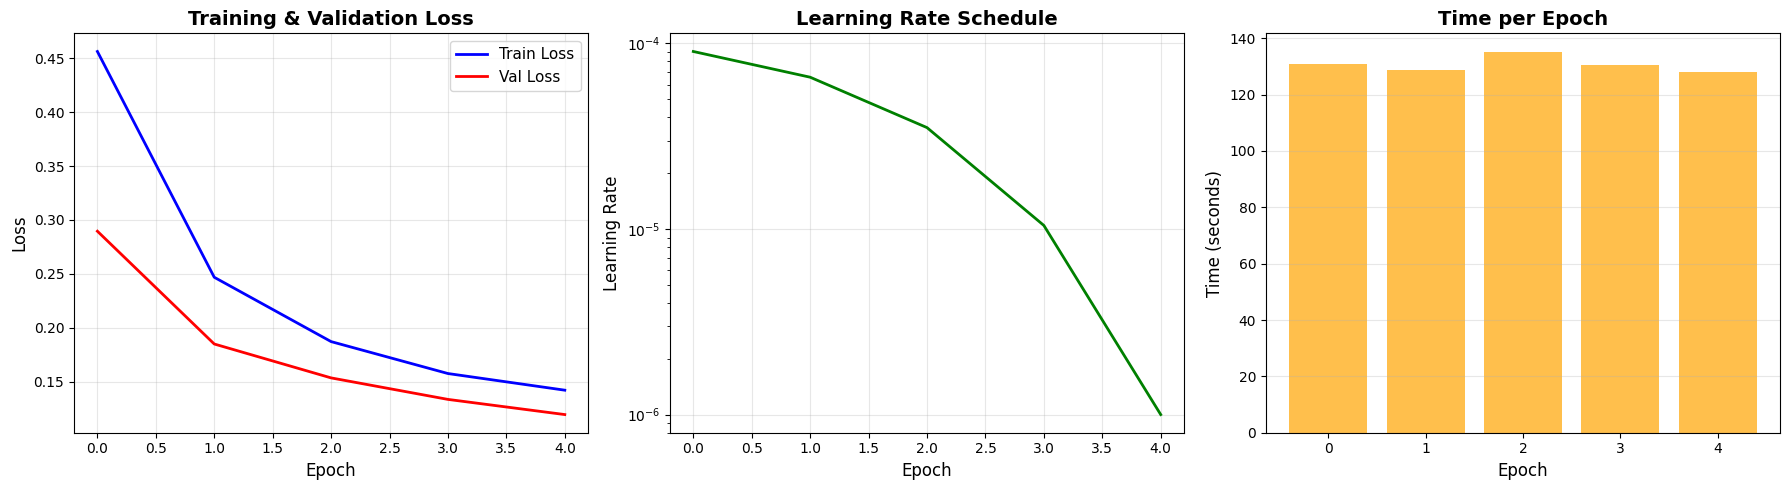


✓ Training curves saved to: C:\\Users\\shrua\\OneDrive\\Desktop\\threshold project\\threshold\\models\\output\training_curves.png


In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Loss curves
epochs_range = range(len(history['train_loss']))
axes[0].plot(epochs_range, history['train_loss'], 'b-', label='Train Loss', linewidth=2)
axes[0].plot(epochs_range, history['val_loss'], 'r-', label='Val Loss', linewidth=2)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss', fontsize=12)
axes[0].set_title('Training & Validation Loss', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# Plot 2: Learning rate
axes[1].plot(epochs_range, history['learning_rate'], 'g-', linewidth=2)
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Learning Rate', fontsize=12)
axes[1].set_title('Learning Rate Schedule', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)
axes[1].set_yscale('log')

# Plot 3: Time per epoch
axes[2].bar(epochs_range, history['epoch_time'], color='orange', alpha=0.7)
axes[2].set_xlabel('Epoch', fontsize=12)
axes[2].set_ylabel('Time (seconds)', fontsize=12)
axes[2].set_title('Time per Epoch', fontsize=14, fontweight='bold')
axes[2].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'training_curves.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f"\n✓ Training curves saved to: {os.path.join(OUTPUT_DIR, 'training_curves.png')}")

## Training Statistics

In [11]:
print("="*80)
print("TRAINING STATISTICS")
print("="*80)
print(f"\nFinal Results:")
print(f"  Final Train Loss: {history['train_loss'][-1]:.4f}")
print(f"  Final Val Loss:   {history['val_loss'][-1]:.4f}")
print(f"  Best Val Loss:    {best_val_loss:.4f} (epoch {np.argmin(history['val_loss'])})")

print(f"\nImprovement:")
print(f"  Train Loss: {history['train_loss'][0]:.4f} → {history['train_loss'][-1]:.4f}")
print(f"  Val Loss:   {history['val_loss'][0]:.4f} → {history['val_loss'][-1]:.4f}")
print(f"  Reduction:  {(1 - history['val_loss'][-1]/history['val_loss'][0])*100:.1f}%")

print(f"\nTiming:")
print(f"  Total time:       {sum(history['epoch_time'])/60:.1f} minutes")
print(f"  Avg time/epoch:   {np.mean(history['epoch_time']):.1f} seconds")
print(f"  Est. for 100 epochs: {np.mean(history['epoch_time'])*100/3600:.1f} hours")

print(f"\nOutput Files:")
print(f"  Best model:        {os.path.join(OUTPUT_DIR, 'checkpoints', 'best_model.pt')}")
print(f"  Final model:       {os.path.join(OUTPUT_DIR, 'checkpoints', 'final_model.pt')}")
print(f"  Pretrained encoder: {os.path.join(OUTPUT_DIR, 'timesformer_encoder_pretrained.pt')}")
print("="*80)

TRAINING STATISTICS

Final Results:
  Final Train Loss: 0.1420
  Final Val Loss:   0.1193
  Best Val Loss:    0.1193 (epoch 4)

Improvement:
  Train Loss: 0.4564 → 0.1420
  Val Loss:   0.2895 → 0.1193
  Reduction:  58.8%

Timing:
  Total time:       10.9 minutes
  Avg time/epoch:   130.6 seconds
  Est. for 100 epochs: 3.6 hours

Output Files:
  Best model:        C:\\Users\\shrua\\OneDrive\\Desktop\\threshold project\\threshold\\models\\output\checkpoints\best_model.pt
  Final model:       C:\\Users\\shrua\\OneDrive\\Desktop\\threshold project\\threshold\\models\\output\checkpoints\final_model.pt
  Pretrained encoder: C:\\Users\\shrua\\OneDrive\\Desktop\\threshold project\\threshold\\models\\output\timesformer_encoder_pretrained.pt


## Next Steps

After pretraining completes:

1. **Load pretrained encoder** for classification fine-tuning
2. **Analyze attention patterns** to validate learning
3. **Visualize embeddings** to understand threshold representations

The pretrained encoder is saved in:
```
output/timesformer_encoder_pretrained.pt
```